In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [102]:
steps_low = c(0.01, 0.1)
steps_mid = c(0.1, 0.5)
steps_high = c(0.5, 1)
novelties = c(0.5, 0.95, 1.25)
communities = paste0('marine', seq(0, length(novelties) - 1), "novelty", novelties)
d1 = data.table(expand.grid(community = communities, ts = steps_low, tg = steps_low, 
                            tf = steps_low,
                            to = steps_mid, tc = steps_high, tp = steps_high,
                            td = steps_high, tr = steps_high,
                            mask = seq(0, 4)))
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    to_read = paste0('output_singlem_dev/opal/tunes', ts, 'g', tg, 'f', tf, 'o', to, 'c', tc,
                     'p', tp, 'd', td, 'r', tr, 'mask', mask, '/', community,'.opal_report')
    if (!file.exists(to_read)) return()
    return(fread(to_read))
}
d2 = d1[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]

In [107]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d2[1:5,]

community,ts,tg,tf,to,tc,tp,td,tr,mask,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF loss,67.078
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF mask loss,108.263
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF penalised loss,97.488
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF steps,5001.000
marine0novelty0.5,0.10,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF loss,66.976


In [104]:
s1 = d2[tool != "Gold standard" & metric == "Bray-Curtis distance"]
s1[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]
setnames(s1, "value", "Bray-Curtis distance")

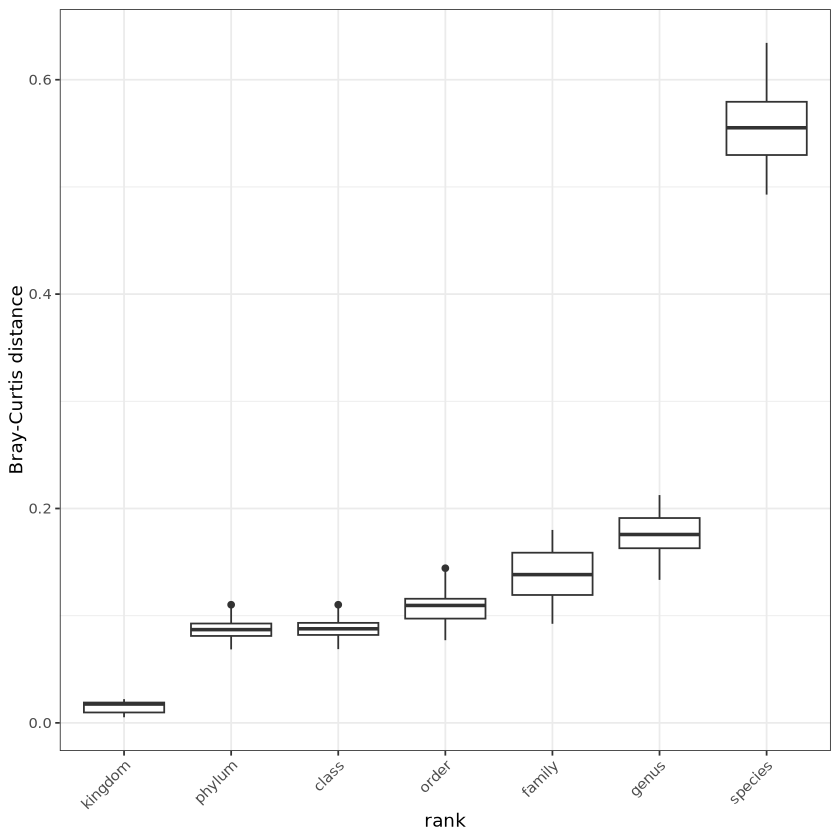

In [105]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# NMF penalty tuning

In [ ]:
readloss = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    to_read = paste0('output_singlem_dev/singlem_dev/tunes', ts, 'g', tg, 'f', tf, 'o', to, 'c', tc,
                     'p', tp, 'd', td, 'r', tr, 'mask', mask, '/', community,'.loss.tsv')
    if (!file.exists(to_read)) return()
    return(fread(to_read, header = FALSE, col.names = c("metric", "value")))
}
d2 = d1[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]

In [108]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d2[1:5,]

community,ts,tg,tf,to,tc,tp,td,tr,mask,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF loss,67.078
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF mask loss,108.263
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF penalised loss,97.488
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF steps,5001.000
marine0novelty0.5,0.10,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF loss,66.976


In [158]:
d2_steps = d2[metric == "NMF steps"]
d2_steps[, metric := NULL]
setnames(d2_steps, "value", "steps")
d3 = d2[!metric %in% c("NMF steps", "NMF penalised loss"), ][d2_steps, on = .NATURAL]

In [166]:
d3[, list(ts = list(ts), value = list(value), steps = list(steps)), by = c("community", "tg", "tf", "to", "tc", "tp", "td", "tr", "metric")]

community,tg,tf,to,tc,tp,td,tr,metric,ts,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<list>,<list>,<list>
marine0novelty0.5,0.01,0.01,0.1,0.5,0.5,0.5,0.5,NMF loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","67.078, 66.976, 70.359, 70.213, 68.946, 69.484, 65.802, 66.030, 59.556, 59.908","5001, 4479, 4893, 3133, 3279, 2815, 5001, 5001, 2869, 2747"
marine0novelty0.5,0.01,0.01,0.1,0.5,0.5,0.5,0.5,NMF mask loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","108.263, 107.117, 83.187, 82.273, 111.039, 110.839, 102.000, 101.320, 119.134, 118.294","5001, 4479, 4893, 3133, 3279, 2815, 5001, 5001, 2869, 2747"
marine0novelty0.5,0.10,0.01,0.1,0.5,0.5,0.5,0.5,NMF loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","67.188, 67.470, 70.285, 70.583, 69.648, 70.368, 69.487, 69.949, 60.085, 60.579","1157, 1020, 846, 639, 1736, 1830, 1649, 974, 1896, 1714"
marine0novelty0.5,0.10,0.01,0.1,0.5,0.5,0.5,0.5,NMF mask loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","107.581, 106.577, 82.554, 81.780, 110.733, 110.721, 98.720, 98.569, 118.474, 117.861","1157, 1020, 846, 639, 1736, 1830, 1649, 974, 1896, 1714"
marine0novelty0.5,0.01,0.10,0.1,0.5,0.5,0.5,0.5,NMF loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","67.547, 67.549, 70.652, 70.758, 69.618, 70.301, 69.556, 69.953, 60.077, 60.450","5001, 4017, 4615, 2848, 2560, 1838, 5001, 3545, 2256, 1700"
marine0novelty0.5,0.01,0.10,0.1,0.5,0.5,0.5,0.5,NMF mask loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","108.270, 107.232, 83.149, 82.157, 111.078, 110.964, 99.253, 98.867, 118.928, 118.240","5001, 4017, 4615, 2848, 2560, 1838, 5001, 3545, 2256, 1700"
marine0novelty0.5,0.10,0.10,0.1,0.5,0.5,0.5,0.5,NMF loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","67.744, 67.931, 70.764, 71.071, 70.481, 71.195, 70.188, 70.613, 60.636, 61.103","940, 710, 654, 640, 699, 646, 945, 853, 921, 1024"
marine0novelty0.5,0.10,0.10,0.1,0.5,0.5,0.5,0.5,NMF mask loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","107.638, 106.806, 82.548, 81.827, 110.779, 110.822, 98.701, 98.629, 118.293, 117.846","940, 710, 654, 640, 699, 646, 945, 853, 921, 1024"
marine0novelty0.5,0.01,0.01,0.5,0.5,0.5,0.5,0.5,NMF loss,"0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10","69.587, 69.635, 73.078, 73.136, 72.298, 72.802, 71.424, 71.739, 62.300, 62.676","5001, 4479, 5001, 3195, 3094, 3575, 5001, 3948, 3023, 2639"


In [ ]:
s1 = d3[
    ,
    list(value = sum(value)),
    by = list(community, ts, tg, tf, to, tc, tp, td, tr, metric, steps)
]
s1[metric == "NMF loss", value := value / 4]
tunecols = c("ts", "tg", "tf", "to", "tc", "tp", "td", "tr")
for (i in seq(2, length(tunecols))) {
    s1[[tunecols[i]]] = s1[[tunecols[i]]] + s1[[tunecols[i-1]]]
}
s1[1:10,]

community,ts,tg,tf,to,tc,tp,td,tr,metric,steps,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.01,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF loss,5001,33.22000
marine0novelty0.5,0.01,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF mask loss,5001,210.26300
marine0novelty0.5,0.10,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,4479,16.74400
marine0novelty0.5,0.10,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF mask loss,4479,107.11700
marine0novelty0.5,0.01,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,1157,16.79700
marine0novelty0.5,0.01,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF mask loss,1157,107.58100
marine0novelty0.5,0.10,0.20,0.21,0.31,0.81,1.31,1.81,2.31,NMF loss,1020,16.86750
marine0novelty0.5,0.10,0.20,0.21,0.31,0.81,1.31,1.81,2.31,NMF mask loss,1020,106.57700
marine0novelty0.5,0.01,0.02,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,5001,34.27575


In [156]:
s1[, list(ts = list(ts), value = list(value)), by = c("community", "tg", "tf", "to", "tc", "tp", "td", "tr", "metric")]

community,tg,tf,to,tc,tp,td,tr,metric,ts,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<list>,<list>
marine0novelty0.5,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF loss,"0.01, 0.01, 0.01, 0.01","33.22000, 17.58975, 17.23650, 14.88900"
marine0novelty0.5,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF mask loss,"0.01, 0.01, 0.01, 0.01","210.263, 83.187, 111.039, 119.134"
marine0novelty0.5,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,"0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01","16.74400, 16.79700, 17.55325, 17.57125, 17.37100, 17.41200, 16.50750, 17.37175, 14.97700, 15.02125"
marine0novelty0.5,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF mask loss,"0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01","107.117, 107.581, 82.273, 82.554, 110.839, 110.733, 101.320, 98.720, 118.294, 118.474"
marine0novelty0.5,0.20,0.21,0.31,0.81,1.31,1.81,2.31,NMF loss,"0.1, 0.1, 0.1, 0.1, 0.1","16.86750, 17.64575, 17.59200, 17.48725, 15.14475"
marine0novelty0.5,0.20,0.21,0.31,0.81,1.31,1.81,2.31,NMF mask loss,"0.1, 0.1, 0.1, 0.1, 0.1","106.577, 81.780, 110.721, 98.569, 117.861"
marine0novelty0.5,0.02,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,"0.01, 0.01, 0.01, 0.01","34.27575, 17.66300, 17.40450, 15.01925"
marine0novelty0.5,0.02,0.12,0.22,0.72,1.22,1.72,2.22,NMF mask loss,"0.01, 0.01, 0.01, 0.01","207.523, 83.149, 111.078, 118.928"
marine0novelty0.5,0.11,0.21,0.31,0.81,1.31,1.81,2.31,NMF loss,"0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01, 0.10, 0.01","16.88725, 16.93600, 17.68950, 17.69100, 17.57525, 17.62025, 17.48825, 17.54700, 15.11250, 15.15900"


In [148]:
plot_rank <- function(data, rank) {
    other_ranks <- setdiff(c("ts", "tg", "tf", "to", "tp", "td", "tr"), rank)
    data[["group"]] <- interaction(data[, other_ranks, with = FALSE])
    ggplot(data, aes(.data[[rank]], value, colour = metric,
                     alpha = steps > 5000,
                     group = interaction(group, metric))) +
   geom_point() +
   geom_line() +
   facet_wrap(vars(community)) +
   theme(legend.title=element_blank()) +
   #theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


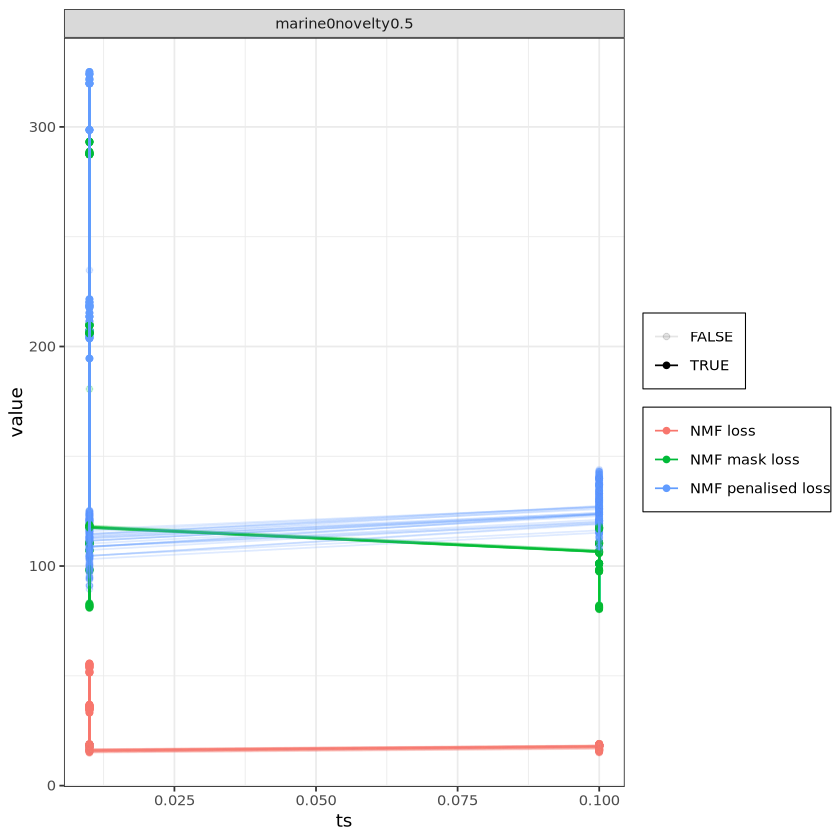

In [149]:
plot_rank(s1, "ts")